# XGBoost OLA — validação operacional honesta

Este notebook investiga se o modelo serve para **priorização operacional**, sem sobrescrever nenhum artefato usado pela API.

Protocolo: treino até junho/2025 → validação no Q3/2025 → teste final intocado no Q4/2025. A escolha de hiperparâmetros usa somente o período de treino; thresholds são definidos no Q3; o Q4 é consultado uma única vez no final.

> Saída segura: `outputs/experiments/xgboost_validacao_operacional.json`. O arquivo `outputs/risco_ola.json` **não é alterado**.

In [1]:
from pathlib import Path
import json
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

def find_project_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'src').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Abra este notebook dentro do repositório Predictfy.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Ajuste apenas se quiser uma execução mais curta ou mais extensa.
RUN_OPTUNA = True
N_TRIALS = 30             # 15 para rápido; 30 recomendado; 60 para busca extensa
N_INNER_SPLITS = 4
N_BOOTSTRAP = 500
RANDOM_STATE = 42

REPORT_DIR = ROOT / 'outputs' / 'experiments'
REPORT_PATH = REPORT_DIR / 'xgboost_validacao_operacional.json'

print(f'Projeto: {ROOT}')
print(f'Python: {platform.python_version()} | XGBoost: {xgb.__version__} | sklearn: {sklearn.__version__}')
print(f'Optuna: {RUN_OPTUNA} ({N_TRIALS} trials) | relatório: {REPORT_PATH}')

Projeto: /Users/pedro/Documents/Estudos/fiap/locaweb
Python: 3.11.11 | XGBoost: 2.1.3 | sklearn: 1.8.0
Optuna: True (30 trials) | relatório: /Users/pedro/Documents/Estudos/fiap/locaweb/outputs/experiments/xgboost_validacao_operacional.json


## 1. Dataset e cortes temporais

As estatísticas de frequência e a taxa histórica por grupo são recalculadas somente com o passado disponível em cada corte. SMOTE, quando usado, é aplicado apenas dentro do treino.

In [2]:
from src.models.xgboost_model import (
    FEATURES, TARGET, _apply_training_statistics, load_data,
)

df = load_data()
dates = df['data_abertura'].dt.normalize()
reference_year = int(dates.max().year)
validation_start = np.datetime64(f'{reference_year}-07-01')
test_start = np.datetime64(f'{reference_year}-10-01')
n_train = int(np.searchsorted(dates.to_numpy(), validation_start, side='left'))
n_validation_end = int(np.searchsorted(dates.to_numpy(), test_start, side='left'))

assert 0 < n_train < n_validation_end < len(df)
assert df['data_abertura'].is_monotonic_increasing

def period_summary(frame):
    return {
        'inicio': frame['data_abertura'].min().isoformat(),
        'fim': frame['data_abertura'].max().isoformat(),
        'incidentes': int(len(frame)),
        'violacoes': int(frame[TARGET].sum()),
        'prevalencia_pct': round(float(frame[TARGET].mean() * 100), 4),
    }

split_summary = {
    'treino': period_summary(df.iloc[:n_train]),
    'validacao_q3': period_summary(df.iloc[n_train:n_validation_end]),
    'teste_q4': period_summary(df.iloc[n_validation_end:]),
}
pd.DataFrame(split_summary).T

,inicio,fim,incidentes,violacoes,prevalencia_pct
treino,2023-02-02T15:52:32,2025-06-30T23:08:03,13625,141,1.0349
validacao_q3,2025-07-01T00:30:46,2025-09-30T22:25:22,6780,57,0.8407
teste_q4,2025-10-01T00:11:30,2025-12-31T18:06:15,5183,50,0.9647


## 2. Funções de treino e avaliação

A métrica de seleção é uma combinação conservadora: `PR-AUC média − 0,25 × desvio padrão` nos folds temporais. Isso penaliza modelos que funcionam muito bem em um período e mal em outro.

In [3]:
COMMON_PARAMS = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'tree_method': 'hist',
}

def concrete_params(spec, y_train):
    params = {**COMMON_PARAMS, **spec['params']}
    if spec['balance'] == 'weighted':
        negatives, positives = np.bincount(np.asarray(y_train, dtype=int), minlength=2)
        params['scale_pos_weight'] = float(negatives / max(1, positives))
    else:
        params.pop('scale_pos_weight', None)
    return params

def fit_spec(X_train, y_train, spec):
    X_fit, y_fit = X_train, y_train
    if spec['balance'] == 'smote':
        positives = int(np.asarray(y_train).sum())
        neighbors = max(1, min(5, positives - 1))
        X_fit, y_fit = SMOTE(
            random_state=RANDOM_STATE, k_neighbors=neighbors
        ).fit_resample(X_train, y_train)
    model = xgb.XGBClassifier(**concrete_params(spec, y_train))
    model.fit(X_fit, y_fit, verbose=False)
    return model

def temporal_cv_spec(raw_df, end, spec, n_splits=N_INNER_SPLITS):
    region = raw_df.iloc[:end].reset_index(drop=True)
    normalized = region['data_abertura'].dt.normalize()
    unique_dates = np.asarray(sorted(normalized.unique()))
    rows = []
    for fold, (train_days, val_days) in enumerate(
        TimeSeriesSplit(n_splits=n_splits).split(unique_dates), start=1
    ):
        train_dates = set(unique_dates[train_days])
        val_dates = set(unique_dates[val_days])
        train_idx = np.flatnonzero(normalized.isin(train_dates).to_numpy())
        val_idx = np.flatnonzero(normalized.isin(val_dates).to_numpy())
        cutoff = int(train_idx[-1]) + 1
        prepared_fold = _apply_training_statistics(region, cutoff)
        y_train_fold = prepared_fold.iloc[train_idx][TARGET].to_numpy()
        y_val_fold = prepared_fold.iloc[val_idx][TARGET].to_numpy()
        if len(np.unique(y_train_fold)) < 2 or len(np.unique(y_val_fold)) < 2:
            continue
        model = fit_spec(
            prepared_fold.iloc[train_idx][FEATURES].to_numpy(), y_train_fold, spec
        )
        probabilities = model.predict_proba(
            prepared_fold.iloc[val_idx][FEATURES].to_numpy()
        )[:, 1]
        rows.append({
            'fold': fold,
            'inicio_validacao': str(pd.Timestamp(unique_dates[val_days][0]).date()),
            'fim_validacao': str(pd.Timestamp(unique_dates[val_days][-1]).date()),
            'n': int(len(y_val_fold)),
            'positivos': int(y_val_fold.sum()),
            'prevalencia': float(y_val_fold.mean()),
            'pr_auc': float(average_precision_score(y_val_fold, probabilities)),
            'roc_auc': float(roc_auc_score(y_val_fold, probabilities)),
        })
    result = pd.DataFrame(rows)
    if result.empty:
        raise ValueError('Nenhum fold temporal contém as duas classes.')
    return result

def summarize_cv(name, frame):
    mean = float(frame['pr_auc'].mean())
    std = float(frame['pr_auc'].std(ddof=0))
    return {
        'modelo': name,
        'pr_auc_media': mean,
        'pr_auc_std': std,
        'roc_auc_media': float(frame['roc_auc'].mean()),
        'score_robusto': mean - 0.25 * std,
        'folds': int(len(frame)),
    }

## 3. Candidatos predefinidos

A comparação inclui o desenho atual, árvores mais regulares, SMOTE e um modelo sem ponderação. O Q3 e o Q4 ainda não são usados nesta etapa.

In [4]:
CANDIDATES = {
    'xgb_atual_ponderado': {
        'balance': 'weighted',
        'params': {
            'n_estimators': 454, 'max_depth': 8, 'learning_rate': 0.0108,
            'subsample': 0.8507, 'colsample_bytree': 0.8277,
            'min_child_weight': 5, 'gamma': 0.648, 'max_delta_step': 8,
            'reg_alpha': 1.74, 'reg_lambda': 3.649,
        },
    },
    'xgb_raso_ponderado': {
        'balance': 'weighted',
        'params': {
            'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03,
            'subsample': 0.85, 'colsample_bytree': 0.80,
            'min_child_weight': 10, 'gamma': 0.3, 'max_delta_step': 3,
            'reg_alpha': 2.0, 'reg_lambda': 8.0,
        },
    },
    'xgb_medio_ponderado': {
        'balance': 'weighted',
        'params': {
            'n_estimators': 550, 'max_depth': 5, 'learning_rate': 0.02,
            'subsample': 0.85, 'colsample_bytree': 0.80,
            'min_child_weight': 8, 'gamma': 0.4, 'max_delta_step': 5,
            'reg_alpha': 2.0, 'reg_lambda': 6.0,
        },
    },
    'xgb_raso_smote': {
        'balance': 'smote',
        'params': {
            'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03,
            'subsample': 0.85, 'colsample_bytree': 0.80,
            'min_child_weight': 10, 'gamma': 0.3, 'max_delta_step': 3,
            'reg_alpha': 2.0, 'reg_lambda': 8.0,
        },
    },
    'xgb_raso_sem_peso': {
        'balance': 'none',
        'params': {
            'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03,
            'subsample': 0.85, 'colsample_bytree': 0.80,
            'min_child_weight': 10, 'gamma': 0.3,
            'reg_alpha': 2.0, 'reg_lambda': 8.0,
        },
    },
}

started = time.perf_counter()
cv_details = {}
cv_summaries = []
for name, spec in CANDIDATES.items():
    print(f'Avaliando {name}...')
    folds = temporal_cv_spec(df, n_train, spec)
    cv_details[name] = folds
    cv_summaries.append(summarize_cv(name, folds))

cv_table = pd.DataFrame(cv_summaries).sort_values('score_robusto', ascending=False)
print(f'Tempo dos candidatos: {time.perf_counter() - started:.1f}s')
cv_table.style.format({
    'pr_auc_media': '{:.4f}', 'pr_auc_std': '{:.4f}',
    'roc_auc_media': '{:.4f}', 'score_robusto': '{:.4f}',
})

Avaliando xgb_atual_ponderado...
Avaliando xgb_raso_ponderado...
Avaliando xgb_medio_ponderado...
Avaliando xgb_raso_smote...
Avaliando xgb_raso_sem_peso...
Tempo dos candidatos: 7.8s


,modelo,pr_auc_media,pr_auc_std,roc_auc_media,score_robusto,folds
0,xgb_atual_ponderado,0.0241,0.0088,0.5454,0.0219,4
3,xgb_raso_smote,0.0204,0.0053,0.5348,0.0191,4
2,xgb_medio_ponderado,0.0215,0.0102,0.5136,0.0189,4
1,xgb_raso_ponderado,0.0192,0.0064,0.5207,0.0176,4
4,xgb_raso_sem_peso,0.0171,0.0048,0.5783,0.0159,4


## 4. Busca Optuna opcional

A busca também usa somente folds anteriores a julho/2025. Para uma primeira execução, 30 trials costuma ser suficiente para saber se há ganho claro.

In [5]:
best_optuna_spec = None
optuna_summary = None

if RUN_OPTUNA:
    try:
        import optuna
    except ModuleNotFoundError:
        RUN_OPTUNA = False
        print('Optuna não está instalado neste kernel. Continuando com os candidatos predefinidos.')
        print('Para habilitar a busca: %pip install optuna==4.8.0')

if RUN_OPTUNA:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        spec = {
            'balance': trial.suggest_categorical('balance', ['weighted', 'none']),
            'params': {
                'n_estimators': trial.suggest_int('n_estimators', 250, 800, step=50),
                'max_depth': trial.suggest_int('max_depth', 2, 7),
                'learning_rate': trial.suggest_float('learning_rate', 0.008, 0.08, log=True),
                'subsample': trial.suggest_float('subsample', 0.65, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.60, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 2, 30),
                'gamma': trial.suggest_float('gamma', 0.0, 3.0),
                'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
            },
        }
        folds = temporal_cv_spec(df, n_train, spec, n_splits=3)
        mean = float(folds['pr_auc'].mean())
        std = float(folds['pr_auc'].std(ddof=0))
        trial.set_user_attr('pr_auc_mean', mean)
        trial.set_user_attr('pr_auc_std', std)
        return mean - 0.25 * std

    started = time.perf_counter()
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    best = study.best_trial
    best_optuna_spec = {
        'balance': best.params['balance'],
        'params': {key: value for key, value in best.params.items() if key != 'balance'},
    }
    CANDIDATES['xgb_optuna_temporal'] = best_optuna_spec
    optuna_folds = temporal_cv_spec(df, n_train, best_optuna_spec)
    cv_details['xgb_optuna_temporal'] = optuna_folds
    optuna_summary = summarize_cv('xgb_optuna_temporal', optuna_folds)
    cv_table = pd.concat([cv_table, pd.DataFrame([optuna_summary])], ignore_index=True)
    cv_table = cv_table.sort_values('score_robusto', ascending=False).reset_index(drop=True)
    print(f'Optuna concluído em {time.perf_counter() - started:.1f}s')
    print(f'Melhor spec: {best_optuna_spec}')
else:
    print('Optuna desativado; usando apenas os candidatos predefinidos.')

cv_table.style.format({
    'pr_auc_media': '{:.4f}', 'pr_auc_std': '{:.4f}',
    'roc_auc_media': '{:.4f}', 'score_robusto': '{:.4f}',
})

Best trial: 10. Best value: 0.0201136: 100%|██████████| 30/30 [00:14<00:00,  2.05it/s]


Optuna concluído em 15.5s
Melhor spec: {'balance': 'none', 'params': {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.03607939886307854, 'subsample': 0.7454404070203796, 'colsample_bytree': 0.9630659181130072, 'min_child_weight': 2, 'gamma': 2.9282357199398956, 'max_delta_step': 4, 'reg_alpha': 0.4520071476614973, 'reg_lambda': 0.11537349692556405}}


,modelo,pr_auc_media,pr_auc_std,roc_auc_media,score_robusto,folds
0,xgb_optuna_temporal,0.0255,0.0118,0.6155,0.0226,4
1,xgb_atual_ponderado,0.0241,0.0088,0.5454,0.0219,4
2,xgb_raso_smote,0.0204,0.0053,0.5348,0.0191,4
3,xgb_medio_ponderado,0.0215,0.0102,0.5136,0.0189,4
4,xgb_raso_ponderado,0.0192,0.0064,0.5207,0.0176,4
5,xgb_raso_sem_peso,0.0171,0.0048,0.5783,0.0159,4


## 5. Seleção no passado e thresholds no Q3

O candidato é escolhido pela validação temporal interna. Em seguida ele é treinado até junho e usado no Q3 para definir políticas de corte. Nenhum número do Q4 participa dessas decisões.

In [6]:
winner_name = str(cv_table.iloc[0]['modelo'])
winner_spec = CANDIDATES[winner_name]
prepared = _apply_training_statistics(df, n_train)
X_train = prepared.iloc[:n_train][FEATURES].to_numpy()
y_train = prepared.iloc[:n_train][TARGET].to_numpy()
X_val = prepared.iloc[n_train:n_validation_end][FEATURES].to_numpy()
y_val = prepared.iloc[n_train:n_validation_end][TARGET].to_numpy()
X_test = prepared.iloc[n_validation_end:][FEATURES].to_numpy()
y_test = prepared.iloc[n_validation_end:][TARGET].to_numpy()

winner_model = fit_spec(X_train, y_train, winner_spec)
p_val = winner_model.predict_proba(X_val)[:, 1]

def threshold_for_recall(y_true, probabilities, target_recall):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    valid = np.where(recall[:-1] >= target_recall)[0]
    return float(thresholds[valid[-1]]) if len(valid) else float(thresholds[0])

def threshold_for_best_f1(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    return float(thresholds[int(np.argmax(f1))])

policies = {
    'recall_30_validacao': threshold_for_recall(y_val, p_val, 0.30),
    'recall_50_validacao': threshold_for_recall(y_val, p_val, 0.50),
    'recall_70_validacao': threshold_for_recall(y_val, p_val, 0.70),
    'max_f1_validacao': threshold_for_best_f1(y_val, p_val),
    'top_1pct_validacao': float(np.quantile(p_val, 0.99)),
    'top_5pct_validacao': float(np.quantile(p_val, 0.95)),
}

validation_metrics = {
    'pr_auc': float(average_precision_score(y_val, p_val)),
    'roc_auc': float(roc_auc_score(y_val, p_val)),
    'prevalencia': float(y_val.mean()),
}
print(f'Vencedor antes do Q3/Q4: {winner_name}')
print(f'Q3 — PR-AUC={validation_metrics["pr_auc"]:.4f} | ROC-AUC={validation_metrics["roc_auc"]:.4f}')
pd.Series(policies, name='threshold').to_frame()

Vencedor antes do Q3/Q4: xgb_optuna_temporal
Q3 — PR-AUC=0.0892 | ROC-AUC=0.7759


,threshold
recall_30_validacao,0.019116
recall_50_validacao,0.010748
recall_70_validacao,0.005807
max_f1_validacao,0.058245
top_1pct_validacao,0.047834
top_5pct_validacao,0.021077


## 6. Abertura do teste Q4 — avaliação final

Daqui em diante o teste é usado apenas para reportar desempenho. Não altere o modelo ou escolha uma política olhando o Q4 e depois o chame novamente de teste intocado.

In [7]:
p_test = winner_model.predict_proba(X_test)[:, 1]
test_days = max(1, prepared.iloc[n_validation_end:]['data_abertura'].dt.normalize().nunique())
test_prevalence = float(y_test.mean())

def evaluate_threshold(name, y_true, probabilities, threshold, days):
    predicted = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    precision = float(precision_score(y_true, predicted, zero_division=0))
    recall = float(recall_score(y_true, predicted, zero_division=0))
    alerts = int(predicted.sum())
    return {
        'politica': name, 'threshold': float(threshold),
        'alertas': alerts, 'alertas_por_dia': float(alerts / days),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
        'precision': precision, 'recall': recall,
        'f1': float(f1_score(y_true, predicted, zero_division=0)),
        'falsos_positivos_pct': float(fp / max(1, alerts)),
        'incidentes_por_acerto': None if tp == 0 else float(alerts / tp),
    }

policy_table = pd.DataFrame([
    evaluate_threshold(name, y_test, p_test, threshold, test_days)
    for name, threshold in policies.items()
]).sort_values('alertas')

def top_k_row(y_true, probabilities, k, days):
    k = int(min(max(1, k), len(y_true)))
    indices = np.argsort(-probabilities, kind='stable')[:k]
    tp = int(np.asarray(y_true)[indices].sum())
    precision = float(tp / k)
    recall = float(tp / max(1, np.asarray(y_true).sum()))
    return {
        'top_k': k, 'alertas_por_dia': float(k / days),
        'violacoes_encontradas': tp, 'precision_at_k': precision,
        'recall_at_k': recall, 'lift_at_k': float(precision / max(test_prevalence, 1e-12)),
        'incidentes_por_acerto': None if tp == 0 else float(k / tp),
    }

ranking_table = pd.DataFrame([
    top_k_row(y_test, p_test, k, test_days)
    for k in (25, 50, 100, 250, 500, 1000) if k <= len(y_test)
])

test_metrics = {
    'pr_auc': float(average_precision_score(y_test, p_test)),
    'roc_auc': float(roc_auc_score(y_test, p_test)),
    'prevalencia': test_prevalence,
    'lift_pr_auc_sobre_acaso': float(average_precision_score(y_test, p_test) / test_prevalence),
    'incidentes': int(len(y_test)),
    'violacoes': int(y_test.sum()),
    'dias': int(test_days),
}
print('MÉTRICAS GERAIS DO TESTE Q4')
display(pd.Series(test_metrics).to_frame('valor'))
print('POLÍTICAS DEFINIDAS NO Q3, APLICADAS SEM ALTERAÇÃO AO Q4')
display(policy_table.style.format({
    'threshold': '{:.5f}', 'alertas_por_dia': '{:.2f}', 'precision': '{:.2%}',
    'recall': '{:.2%}', 'f1': '{:.2%}', 'falsos_positivos_pct': '{:.2%}',
    'incidentes_por_acerto': '{:.1f}',
}))
print('CURVA DE CAPACIDADE / TOP-K NO Q4')
display(ranking_table.style.format({
    'alertas_por_dia': '{:.2f}', 'precision_at_k': '{:.2%}',
    'recall_at_k': '{:.2%}', 'lift_at_k': '{:.1f}×', 'incidentes_por_acerto': '{:.1f}',
}))

MÉTRICAS GERAIS DO TESTE Q4


,valor
pr_auc,0.213211
roc_auc,0.865200
prevalencia,0.009647
lift_pr_auc_sobre_acaso,22.101455
incidentes,5183.000000
violacoes,50.000000
dias,92.000000


POLÍTICAS DEFINIDAS NO Q3, APLICADAS SEM ALTERAÇÃO AO Q4


,politica,threshold,alertas,alertas_por_dia,tp,fp,fn,tn,precision,recall,f1,falsos_positivos_pct,incidentes_por_acerto
3,max_f1_validacao,0.05825,92,1.00,17,75,33,5058,18.48%,34.00%,23.94%,81.52%,5.4
4,top_1pct_validacao,0.04783,129,1.40,20,109,30,5024,15.50%,40.00%,22.35%,84.50%,6.5
5,top_5pct_validacao,0.02108,465,5.05,30,435,20,4698,6.45%,60.00%,11.65%,93.55%,15.5
0,recall_30_validacao,0.01912,512,5.57,30,482,20,4651,5.86%,60.00%,10.68%,94.14%,17.1
1,recall_50_validacao,0.01075,933,10.14,35,898,15,4235,3.75%,70.00%,7.12%,96.25%,26.7
2,recall_70_validacao,0.00581,1718,18.67,43,1675,7,3458,2.50%,86.00%,4.86%,97.50%,40.0


CURVA DE CAPACIDADE / TOP-K NO Q4


,top_k,alertas_por_dia,violacoes_encontradas,precision_at_k,recall_at_k,lift_at_k,incidentes_por_acerto
0,25,0.27,11,44.00%,22.00%,45.6×,2.3
1,50,0.54,13,26.00%,26.00%,27.0×,3.8
2,100,1.09,18,18.00%,36.00%,18.7×,5.6
3,250,2.72,26,10.40%,52.00%,10.8×,9.6
4,500,5.43,30,6.00%,60.00%,6.2×,16.7
5,1000,10.87,35,3.50%,70.00%,3.6×,28.6


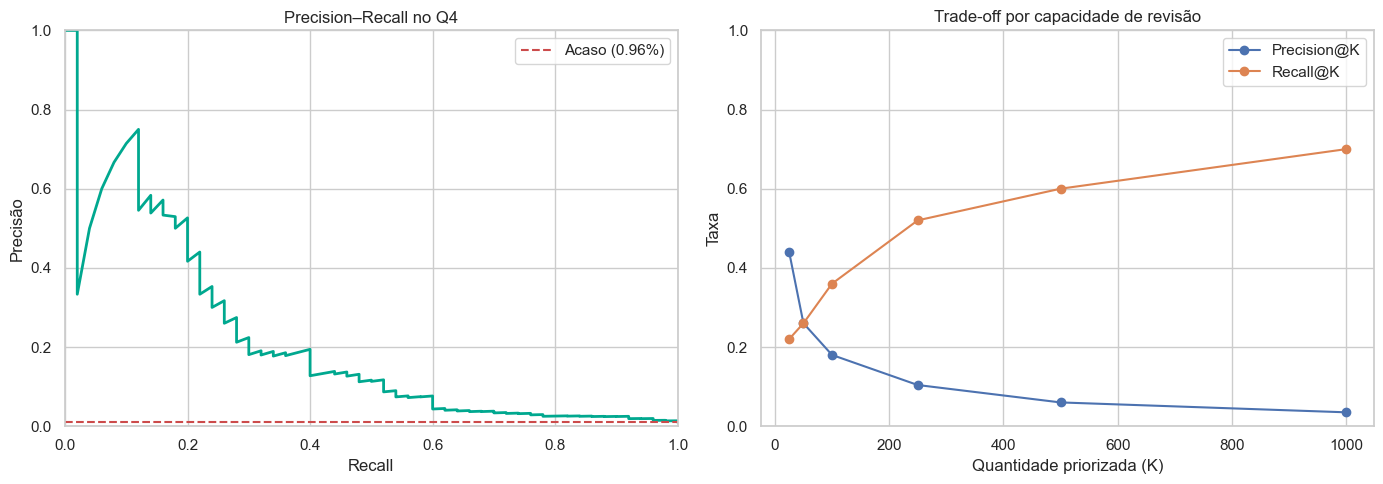

In [8]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, p_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(recall_curve, precision_curve, color='#00a88f', linewidth=2)
axes[0].axhline(test_prevalence, color='#cc4b4b', linestyle='--', label=f'Acaso ({test_prevalence:.2%})')
axes[0].set(title='Precision–Recall no Q4', xlabel='Recall', ylabel='Precisão', xlim=(0, 1), ylim=(0, 1))
axes[0].legend()
axes[1].plot(ranking_table['top_k'], ranking_table['precision_at_k'], marker='o', label='Precision@K')
axes[1].plot(ranking_table['top_k'], ranking_table['recall_at_k'], marker='o', label='Recall@K')
axes[1].set(title='Trade-off por capacidade de revisão', xlabel='Quantidade priorizada (K)', ylabel='Taxa', ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. P2 × P3, incerteza e importância

Separar os segmentos ajuda a detectar um modelo que ordena bem P3, mas falha em P2. O bootstrap mostra a incerteza causada pelos poucos casos positivos.

In [9]:
test_frame = prepared.iloc[n_validation_end:].copy()
test_frame['score'] = p_test
segment_rows = []
for priority_value, priority_name in ((1, 'P2'), (0, 'P3')):
    segment = test_frame[test_frame['prioridade_bin'] == priority_value]
    y_segment = segment[TARGET].to_numpy()
    p_segment = segment['score'].to_numpy()
    row = {
        'prioridade': priority_name, 'incidentes': int(len(segment)),
        'violacoes': int(y_segment.sum()), 'prevalencia': float(y_segment.mean()),
        'pr_auc': float(average_precision_score(y_segment, p_segment)),
        'roc_auc': float(roc_auc_score(y_segment, p_segment)),
    }
    for share in (0.01, 0.05, 0.10):
        k = max(1, int(round(len(segment) * share)))
        indices = np.argsort(-p_segment, kind='stable')[:k]
        hits = int(y_segment[indices].sum())
        label = int(share * 100)
        row[f'precision_top_{label}pct'] = float(hits / k)
        row[f'recall_top_{label}pct'] = float(hits / max(1, y_segment.sum()))
    segment_rows.append(row)
segment_table = pd.DataFrame(segment_rows)
display(segment_table.style.format({
    col: '{:.2%}' for col in segment_table.columns
    if col not in {'prioridade', 'incidentes', 'violacoes'}
}))

rng = np.random.default_rng(RANDOM_STATE)
bootstrap_pr_auc = []
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, len(y_test), size=len(y_test))
    y_boot = y_test[idx]
    if len(np.unique(y_boot)) == 2:
        bootstrap_pr_auc.append(average_precision_score(y_boot, p_test[idx]))
pr_auc_ci = {
    'n_bootstrap_validos': len(bootstrap_pr_auc),
    'p2_5': float(np.quantile(bootstrap_pr_auc, 0.025)),
    'mediana': float(np.quantile(bootstrap_pr_auc, 0.50)),
    'p97_5': float(np.quantile(bootstrap_pr_auc, 0.975)),
}
print(f'IC bootstrap 95% da PR-AUC: {pr_auc_ci["p2_5"]:.4f} — {pr_auc_ci["p97_5"]:.4f}')

gain = winner_model.get_booster().get_score(importance_type='gain')
importance_rows = []
for key, value in gain.items():
    index = int(key[1:]) if key.startswith('f') and key[1:].isdigit() else None
    feature = FEATURES[index] if index is not None and index < len(FEATURES) else key
    importance_rows.append({'feature': feature, 'gain': float(value)})
importance_table = pd.DataFrame(importance_rows).sort_values('gain', ascending=False).head(20)
display(importance_table)

,prioridade,incidentes,violacoes,prevalencia,pr_auc,roc_auc,precision_top_1pct,recall_top_1pct,precision_top_5pct,recall_top_5pct,precision_top_10pct,recall_top_10pct
0,P2,1248,9,0.72%,2.76%,80.07%,0.00%,0.00%,3.23%,22.22%,3.20%,44.44%
1,P3,3935,41,1.04%,26.34%,88.84%,33.33%,31.71%,11.68%,56.10%,6.60%,63.41%


IC bootstrap 95% da PR-AUC: 0.1179 — 0.3448


,feature,gain
26,grupo_viol_rate,6.645044
16,categoria_enc,6.057839
20,produto_freq,5.986729
15,produto_enc,5.678394
14,prioridade_bin,5.512944
2,mes,5.312960
19,aberto_por_enc,5.174248
7,periodo_dia,5.167301
9,lag_7d,5.122127
17,subcategoria_enc,5.103262


## 8. Exportar relatório seguro

Execute esta célula e envie o arquivo gerado ou copie o bloco `RESULTADO_PARA_ENVIAR`. Ele contém apenas métricas e parâmetros, sem incidentes individuais ou dados sensíveis.

In [10]:
def frame_records(frame):
    return json.loads(frame.to_json(orient='records'))

def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value

report = {
    'relatorio': 'xgboost_validacao_operacional',
    'protocolo': 'inner_cv_ate_jun_selecao_threshold_q3_teste_unico_q4',
    'seguranca': {
        'sobrescreve_producao': False,
        'artefato_producao_preservado': 'outputs/risco_ola.json',
    },
    'ambiente': {
        'python': platform.python_version(), 'xgboost': xgb.__version__,
        'sklearn': sklearn.__version__, 'platform': platform.platform(),
    },
    'configuracao': {
        'run_optuna': RUN_OPTUNA, 'n_trials': N_TRIALS if RUN_OPTUNA else 0,
        'inner_splits': N_INNER_SPLITS, 'bootstrap': N_BOOTSTRAP,
    },
    'splits': split_summary,
    'comparacao_cv_interno': frame_records(cv_table),
    'vencedor': {
        'nome': winner_name, 'spec': winner_spec,
        'params_concretos': concrete_params(winner_spec, y_train),
    },
    'validacao_q3': validation_metrics,
    'thresholds_definidos_q3': policies,
    'teste_q4': test_metrics,
    'politicas_no_teste': frame_records(policy_table),
    'ranking_top_k_teste': frame_records(ranking_table),
    'segmentos_teste': frame_records(segment_table),
    'pr_auc_bootstrap_ic95': pr_auc_ci,
    'top_features_gain': frame_records(importance_table),
}
report = json_safe(report)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
with REPORT_PATH.open('w', encoding='utf-8') as report_file:
    json.dump(report, report_file, ensure_ascii=False, indent=2, allow_nan=False)

best_policy_recall_30 = policy_table[policy_table['recall'] >= 0.30].sort_values('precision', ascending=False)
best_policy_summary = None if best_policy_recall_30.empty else frame_records(best_policy_recall_30.head(1))[0]
resultado_para_enviar = {
    'vencedor': winner_name,
    'cv_pr_auc_media': float(cv_table.iloc[0]['pr_auc_media']),
    'cv_pr_auc_std': float(cv_table.iloc[0]['pr_auc_std']),
    'q3_pr_auc': validation_metrics['pr_auc'],
    'q4_pr_auc': test_metrics['pr_auc'],
    'q4_pr_auc_ic95': [pr_auc_ci['p2_5'], pr_auc_ci['p97_5']],
    'q4_prevalencia': test_metrics['prevalencia'],
    'q4_lift_pr_auc': test_metrics['lift_pr_auc_sobre_acaso'],
    'melhor_politica_com_recall_min_30pct': best_policy_summary,
    'ranking_top_k': frame_records(ranking_table),
    'segmentos': frame_records(segment_table),
    'relatorio': str(REPORT_PATH),
}

print(f'Relatório salvo sem alterar produção: {REPORT_PATH}')
print('\nRESULTADO_PARA_ENVIAR\n')
print(json.dumps(json_safe(resultado_para_enviar), ensure_ascii=False, indent=2, allow_nan=False))

Relatório salvo sem alterar produção: /Users/pedro/Documents/Estudos/fiap/locaweb/outputs/experiments/xgboost_validacao_operacional.json

RESULTADO_PARA_ENVIAR

{
  "vencedor": "xgb_optuna_temporal",
  "cv_pr_auc_media": 0.025515670790144662,
  "cv_pr_auc_std": 0.011801214683432351,
  "q3_pr_auc": 0.08917639208233426,
  "q4_pr_auc": 0.2132110268129056,
  "q4_pr_auc_ic95": [
    0.11787524229212168,
    0.3447779490166032
  ],
  "q4_prevalencia": 0.009646922631680493,
  "q4_lift_pr_auc": 22.101455039425797,
  "melhor_politica_com_recall_min_30pct": {
    "politica": "max_f1_validacao",
    "threshold": 0.0582451485,
    "alertas": 92,
    "alertas_por_dia": 1.0,
    "tp": 17,
    "fp": 75,
    "fn": 33,
    "tn": 5058,
    "precision": 0.1847826087,
    "recall": 0.34,
    "f1": 0.2394366197,
    "falsos_positivos_pct": 0.8152173913,
    "incidentes_por_acerto": 5.4117647059
  },
  "ranking_top_k": [
    {
      "top_k": 25,
      "alertas_por_dia": 0.2717391304,
      "violacoes_encont

## Como me devolver o resultado

Você pode:

1. Anexar `outputs/experiments/xgboost_validacao_operacional.json`; ou
2. Copiar todo o bloco `RESULTADO_PARA_ENVIAR` da última célula.

Se ocorrer erro, envie o traceback completo e informe em qual célula aconteceu.